# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [2]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

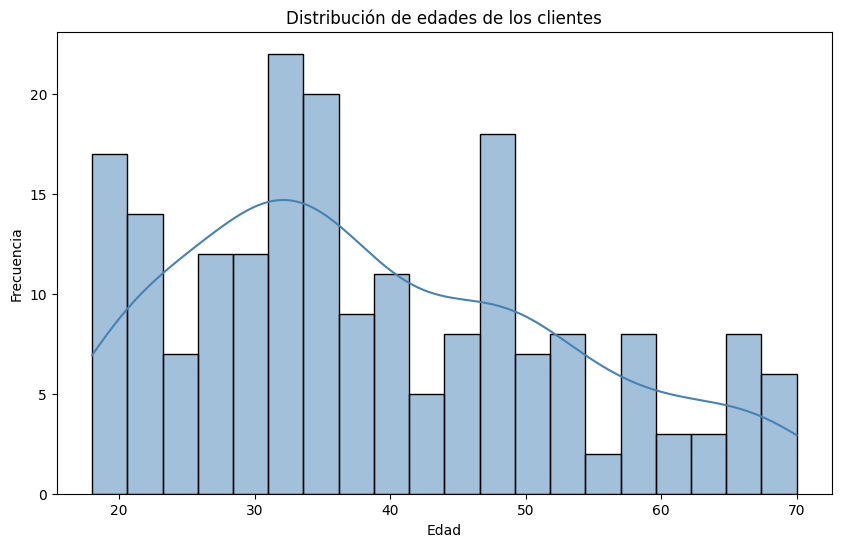

In [3]:
# tu código aquí
df = pd.read_csv('./data/retailmax.csv')

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=20, color='steelblue')
plt.title('Distribución de edades de los clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

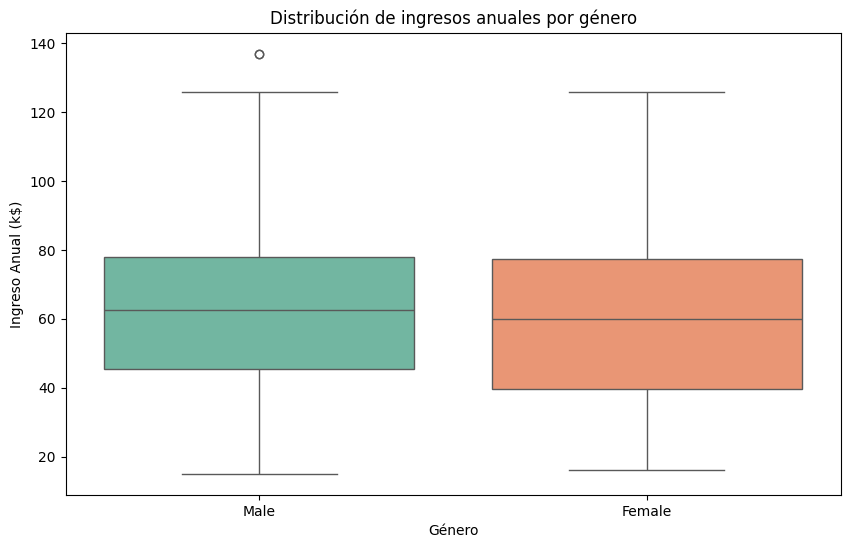

In [4]:
# tu código aquí

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Gender', y='Annual Income (k$)', palette='Set2')
plt.title('Distribución de ingresos anuales por género')
plt.xlabel('Género')
plt.ylabel('Ingreso Anual (k$)')
plt.show()

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

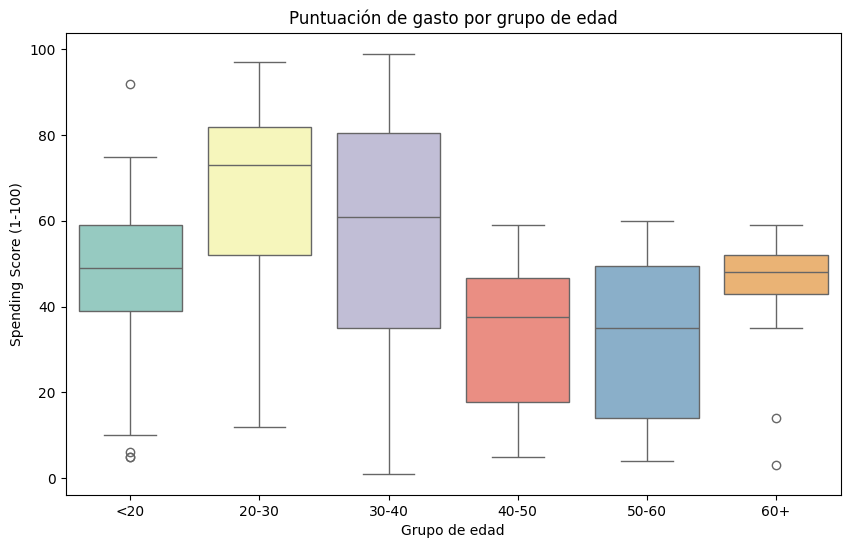

In [5]:
df['Grupo de edad'] = pd.cut(df['Age'], bins=[0, 20, 30, 40, 50, 60, 100],
                               labels=['<20', '20-30', '30-40', '40-50', '50-60', '60+'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Grupo de edad', y='Spending Score (1-100)', palette='Set3')
plt.title('Puntuación de gasto por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Spending Score (1-100)')
plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

Coeficiente de correlación: 0.0099


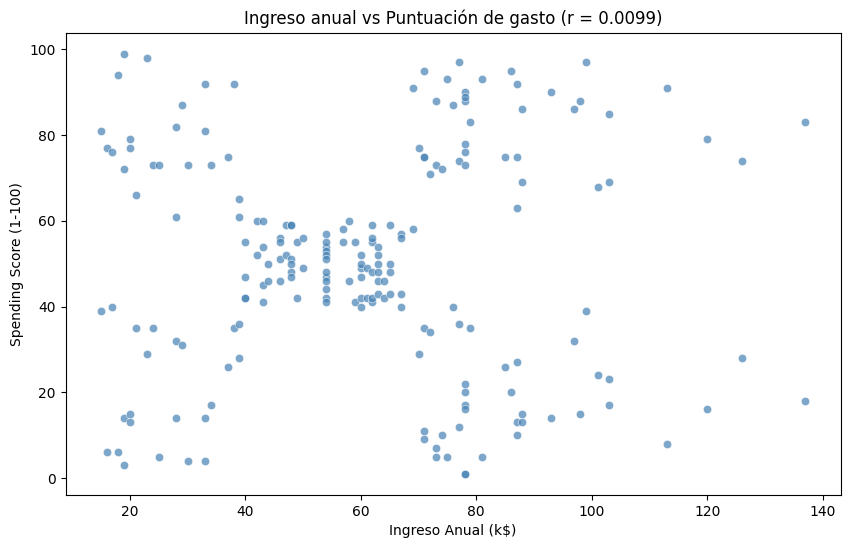

In [6]:
correlacion = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
print(f'Coeficiente de correlación: {correlacion:.4f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', color='steelblue', alpha=0.7)
plt.title(f'Ingreso anual vs Puntuación de gasto (r = {correlacion:.4f})')
plt.xlabel('Ingreso Anual (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

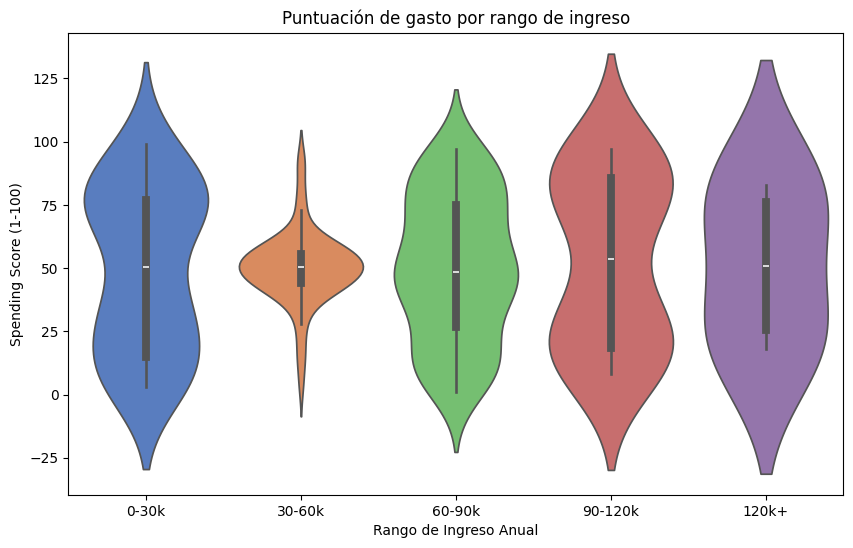

In [7]:
# tu código aquí
df['Rango de ingreso'] = pd.cut(df['Annual Income (k$)'], bins=[0, 30, 60, 90, 120, 200],
                                   labels=['0-30k', '30-60k', '60-90k', '90-120k', '120k+'])

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Rango de ingreso', y='Spending Score (1-100)', palette='muted')
plt.title('Puntuación de gasto por rango de ingreso')
plt.xlabel('Rango de Ingreso Anual')
plt.ylabel('Spending Score (1-100)')
plt.show()

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

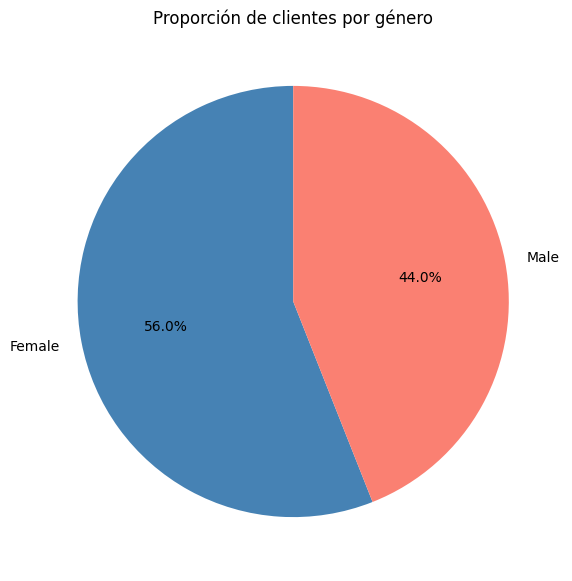

In [8]:
# tu código aquí
proporcion = df['Gender'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(proporcion, labels=proporcion.index, autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
plt.title('Proporción de clientes por género')
plt.show()

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

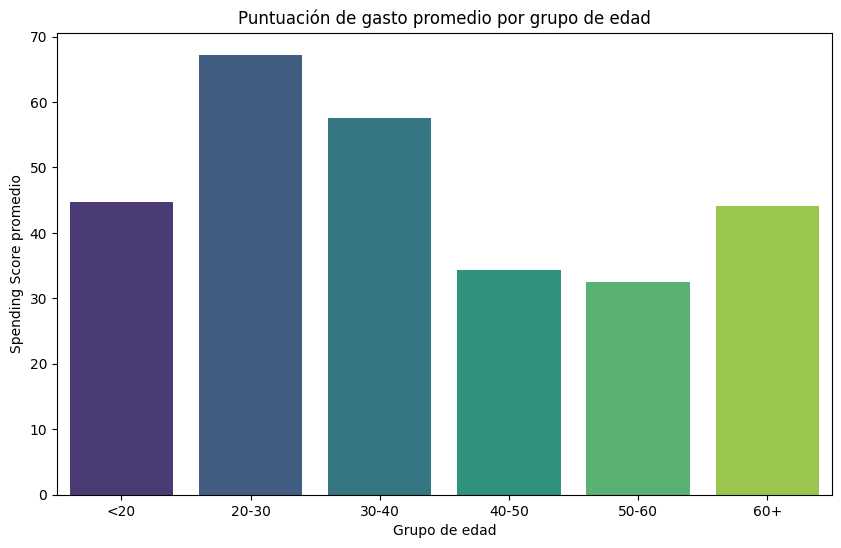

In [9]:
gasto_por_edad = df.groupby('Grupo de edad', observed=True)['Spending Score (1-100)'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=gasto_por_edad, x='Grupo de edad', y='Spending Score (1-100)', palette='viridis')
plt.title('Puntuación de gasto promedio por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Spending Score promedio')
plt.show()

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

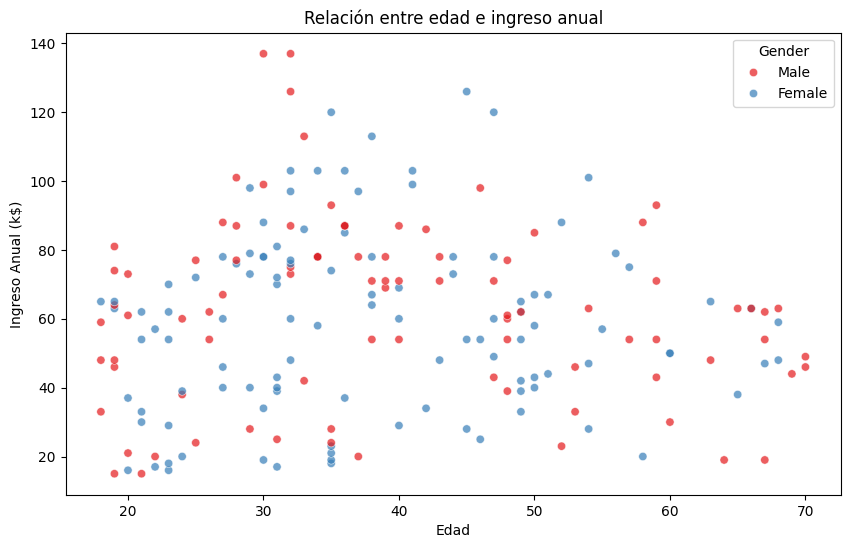

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Annual Income (k$)', hue='Gender', palette='Set1', alpha=0.7)
plt.title('Relación entre edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso Anual (k$)')
plt.show()

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

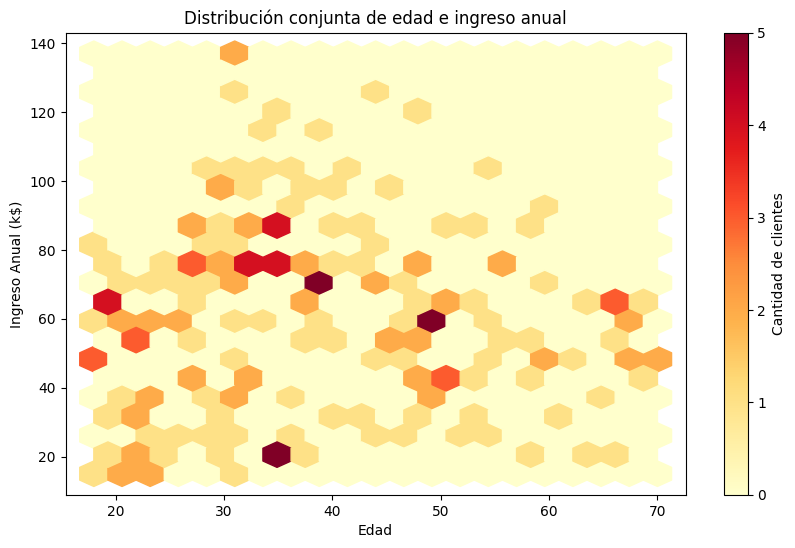

In [11]:
plt.figure(figsize=(10, 6))
plt.hexbin(df['Age'], df['Annual Income (k$)'], gridsize=20, cmap='YlOrRd')
plt.colorbar(label='Cantidad de clientes')
plt.title('Distribución conjunta de edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso Anual (k$)')
plt.show()

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

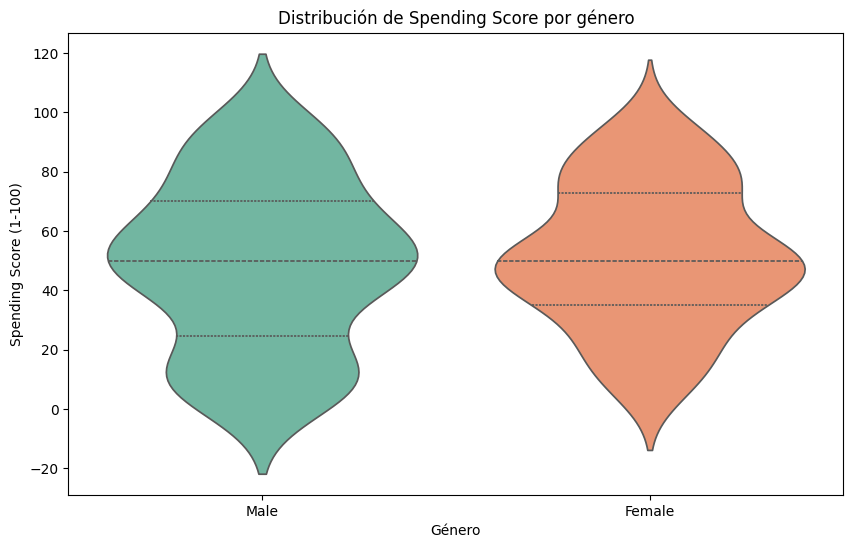

In [12]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Gender', y='Spending Score (1-100)', palette='Set2', inner='quartile')
plt.title('Distribución de Spending Score por género')
plt.xlabel('Género')
plt.ylabel('Spending Score (1-100)')
plt.show()